In [22]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
df=pd.read_excel("/content/drive/MyDrive/Dataset/Online Retail.xlsx")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,NaN,71053.0,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365.0,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365.0,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity              float64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## separating numerical and object variables

In [ ]:
num=df.select_dtypes(include="number")
char=df.select_dtypes(include="object")

In [ ]:
num.head(3)

,Quantity,UnitPrice,CustomerID
0,6.0,2.55,17850.0
1,6.0,3.39,17850.0
2,8.0,2.75,17850.0


In [ ]:
char.head(3)

,InvoiceNo,StockCode,Description,Country
0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,NaN,71053.0,WHITE METAL LANTERN,United Kingdom
2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom


In [ ]:
char["cancelation"]=list(map(lambda t:'Yes' if str(t)[0]=='C' else 'No' ,df["InvoiceNo"]))
# df['quartile']=list(map(lambda t:'q3' if t in ['jan','feb','mar'] 
#                        else ('q1' if t in ['apr','may','jun'] 
#                              else ('q2' if t in ['jul','aug','sep'] else 'q4')) ,df['month']))

In [ ]:
char["StockCode"].value_counts()

85123A     2313
22423.0    2203
85099B     2159
47566.0    1727
20725.0    1639
           ... 
21431.0       1
22275.0       1
17001.0       1
90187A        1
72759.0       1
Name: StockCode, Length: 4070, dtype: int64

In [ ]:
char["Country"].value_counts()

United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon 

In [ ]:
# as most of the values from uk,converting it into uk/non-uk column
char["UK/!UK"]=list(map(lambda x:'Yes' if x=="United Kingdom" else 'No',df["Country"]))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
char['timeOfDay']=(df['InvoiceDate'].dt.hour%24+4)//6     #to use dt we have to change it to datetime field
char['timeOfDay'].replace({2: 'Morning',
                      3: 'Noon',
                      4: 'Evening',
                      1: 'Night'},inplace=True)
# df[df['timeOfDay1']=='Morning'].head(10)
char.head(3)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


,InvoiceNo,StockCode,Description,Country,cancelation,UK/!UK,timeOfDay
0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,No,Yes,Morning
1,NaN,71053.0,WHITE METAL LANTERN,United Kingdom,No,Yes,Morning
2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom,No,Yes,Morning


In [ ]:
char['month']=(df['InvoiceDate'].dt.month_name) #to use dt we have to change it to datetime field
char['month']=list(map(lambda t : t.lower()[0:3],char['month']))
# df['month']=list(map(lambda t : t[0:3],df['month']))
char.head(3)

AttributeError: ignored

In [ ]:
char['quartile']=list(map(lambda t:'q3' if t in ['jan','feb','mar'] 
                       else ('q1' if t in ['apr','may','jun'] 
                             else ('q2' if t in ['jul','aug','sep'] else 'q4')) ,char['month']))

In [ ]:
char['dayOfWeek']=df['InvoiceDate'].dt.day_name()
char['dayOfWeek']=list(map(lambda t : t.lower()[0:3],char['dayOfWeek']))

In [ ]:
char1.head(3)

,cancelation,UK/!UK,timeOfDay,month,quartile,dayOfWeek
0,No,Yes,Morning,dec,q4,wed
1,No,Yes,Morning,dec,q4,wed
2,No,Yes,Morning,dec,q4,wed


In [ ]:
num["weekOfYear"]=df['InvoiceDate'].dt.isocalendar().week

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [ ]:
num1=num.drop(['CustomerID'],axis='columns') #dropping stockcode as
# it is a alphanumeric column  andif we do one hot encoding it will cretae too many columns
# "InvoiceNo",'Description','CustomerID',"StockCode",

In [ ]:
char1=char.drop(["InvoiceNo",'Description',"StockCode","Country"],axis='columns')

## One hot encoding of character featuers

In [ ]:
X_char_dum = pd.get_dummies(char1, drop_first = True)
X_char_dum.shape

(541909, 24)

In [ ]:
num1.describe()

,Quantity,UnitPrice,weekOfYear
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,30.729049
std,218.081158,96.759853,15.146243
min,-80995.000000,-11062.060000,1.000000
25%,1.000000,1.250000,18.000000
50%,3.000000,2.080000,34.000000
75%,10.000000,4.130000,45.000000
max,80995.000000,38970.000000,51.000000


## Standardisation using standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
stdsc=StandardScaler()
num_stdsc=pd.DataFrame(stdsc.fit_transform(num1),index=num1.index,columns=num1.columns).add_suffix('_std')

In [ ]:
num_stdsc.describe()

,Quantity_std,UnitPrice_std,weekOfYear_std
count,5.419090e+05,5.419090e+05,5.419090e+05
mean,2.242126e-18,-1.402968e-18,-5.370612e-17
std,1.000001e+00,1.000001e+00,1.000001e+00
min,-3.714426e+02,-1.143727e+02,-1.962802e+00
25%,-3.921594e-02,-3.473669e-02,-8.404104e-01
50%,-3.004503e-02,-2.615874e-02,2.159581e-01
75%,2.053139e-03,-4.972249e-03,9.422115e-01
max,3.713550e+02,4.027024e+02,1.338350e+00


In [ ]:
final_df=pd.concat([num_stdsc,X_char_dum],axis=1,join="inner")

## Setting Display options to ensure feature name visibility

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
final_df.head(3)

,Quantity_std,UnitPrice_std,weekOfYear_std,cancelation_Yes,UK/!UK_Yes,timeOfDay_Morning,timeOfDay_Night,timeOfDay_Noon,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,quartile_q2,quartile_q3,quartile_q4,dayOfWeek_mon,dayOfWeek_sun,dayOfWeek_thu,dayOfWeek_tue,dayOfWeek_wed
0,-0.016289,-0.021301,1.140281,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
1,-0.016289,-0.012620,1.140281,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,-0.007118,-0.019234,1.140281,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1


## WCSS 

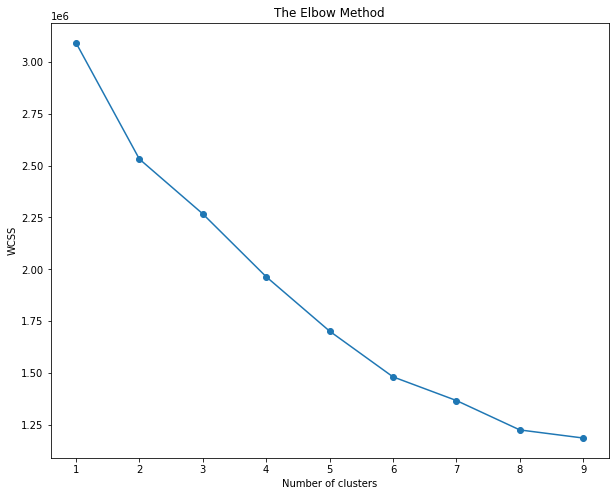

In [ ]:
# find the appropriate cluster number
plt.figure(figsize=(10, 8))
from sklearn.cluster import KMeans
wcss = []
K = range(1, 10)
for i in K:
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(final_df)
    wcss.append(kmeans.inertia_)
plt.plot(K, wcss,'o-')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Building Clusters

In [ ]:
# Fitting K-Means to the dataset
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 6, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(final_df)
final_df['cluster_label'] = pd.DataFrame(y_kmeans)

In [ ]:
num['cluster_label']=final_df['cluster_label']

In [ ]:
num['cluster_label'].value_counts()

1    228846
0    213451
2     99598
5        10
3         2
4         2
Name: cluster_label, dtype: int64

In [ ]:
cluster_label=final_df['cluster_label']

In [ ]:
cluster_label.shape

(541909,)

In [ ]:
final_df.shape

(541909, 28)

In [ ]:
#high silhouette coefficients will indicate that clusters are actually, well, separated.
# from sklearn.metrics import silhouette_score
# silhouette_avg = silhouette_score(final_df, cluster_label)
# silhouette_avg

In [ ]:
# low enough DB score will indicate that observation that a falling into the same cluster are similar
# from sklearn.metrics import davies_bouldin_score
# davies_bouldin_score(final_df,cluster_label)

## Joining the dataframes num and char

In [ ]:
data_all=pd.concat([num,char],axis=1,join="inner")

In [ ]:
data_all.to_csv("gifting_cluster_withCategorical.csv")



```
# This is formatted as code
```

Cluster 0 -> AvgQty - 9 | AvgPrice - 4.22 | Q4 | international demand | <0.1% Cancel | thru out the day AND week | winters

Cluster 1 -> AvgQty - 10 | AvgPrice - 4.33 | Q1 Q2 | international demand | <0.1% Cancel | thru out the day AND week | summers

Cluster 2 -> AvgQty - 10 | AvgPrice - 4.40 | Q3 | international demand | <0.1% Cancel | thru out the day AND week | spring

Cluster 3 -> BULK ORDER

Cluster 4 -> RETURN BULK

Cluster5 -> Fees


## Remove the cluster 3,4,5 Rows 

In [ ]:
values=[3,4,5]
data_all1 = data_all[data_all["cluster_label"].isin(values) == False]

In [ ]:
data_all1["cluster_label"].value_counts()

1    228846
0    213451
2     99598
Name: cluster_label, dtype: int64

In [ ]:
data_all1.head(3)

,Quantity,UnitPrice,CustomerID,weekOfYear,cluster_label,InvoiceNo,StockCode,Description,Country,cancelation,UK/!UK,timeOfDay,month,quartile,dayOfWeek
0,6,2.55,17850.0,48,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,No,Yes,Morning,dec,q4,wed
1,6,3.39,17850.0,48,0,536365,71053,WHITE METAL LANTERN,United Kingdom,No,Yes,Morning,dec,q4,wed
2,8,2.75,17850.0,48,0,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom,No,Yes,Morning,dec,q4,wed


In [ ]:
data_all2=data_all1.drop(["InvoiceNo",'Description',"StockCode","Country","CustomerID","cluster_label"],axis='columns')

In [ ]:
num1=data_all2.select_dtypes(include="number")
char1=data_all2.select_dtypes(include="object")

In [ ]:
X_char_dum1 = pd.get_dummies(char1, drop_first = True)
X_char_dum1.shape

(541895, 24)

In [ ]:
stdsc1=StandardScaler()
num_stdsc1=pd.DataFrame(stdsc1.fit_transform(num1),index=num1.index,columns=num1.columns).add_suffix('_std')

In [ ]:
final_df1=pd.concat([num_stdsc1,X_char_dum1],axis=1,join="inner")

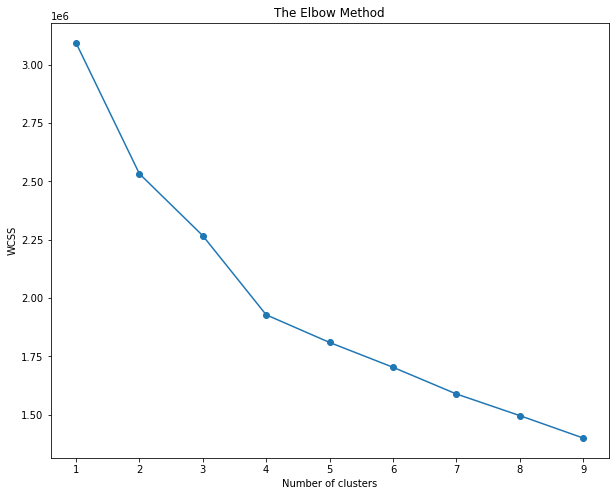

In [ ]:
# find the appropriate cluster number
plt.figure(figsize=(10, 8))
from sklearn.cluster import KMeans
wcss = []
K = range(1, 10)
for i in K:
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(final_df1)
    wcss.append(kmeans.inertia_)
plt.plot(K, wcss,'o-')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans1 = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans1 = kmeans1.fit_predict(final_df1)
final_df1['cluster_label'] = pd.DataFrame(y_kmeans)

In [ ]:
final_df1['cluster_label'].value_counts()

1    228846
0    213451
2     99598
Name: cluster_label, dtype: int64

In [ ]:
df=data_all1.drop(["cluster_label"],axis=1)

In [ ]:
data_all_final=pd.concat([df,final_df1['cluster_label']],axis=1,join="inner")

In [ ]:
data_all_final.to_csv("gifting_cluster_withCategorical_v1.csv")